# Tutorial 7.2: Dynamic optimisation and flexible building assets

This tutorial extends the heat-pump schedule with PV, base demand and a battery. The thermal schedule is kept fixed so that the new work remains focused on state-of-charge dynamics and the site electricity balance.

## Learning outcomes

By the end of the tutorial, you should be able to:

1. formulate a battery energy-state equation;
2. enforce one consistent site electricity balance;
3. distinguish power from stored energy; and
4. compare cost, peak demand and event-period flexibility.

## Indicative schedule

- heat-pump schedule and site data: 15 minutes;
- battery and balance constraints: 35 minutes;
- objective and solution checks: 20 minutes;
- plots and flexibility metrics: 15 minutes;
- discussion: 5 minutes.

## 1. Set-up and fixed thermal schedule

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from course_utils.control import solve_heating_schedule

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    raise FileNotFoundError("Run this notebook from the repository root.")

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})

In [2]:
conditions = pd.read_csv(
    ROOT / "data" / "reference_building" / "operation_conditions.csv",
    index_col="timestamp",
    parse_dates=True,
).iloc[:48]
model = json.loads(
    (ROOT / "data" / "reference_building" / "verified_controller_model.json").read_text()
)
heating_solution = solve_heating_schedule(conditions, model)
heat_pump_power_kw = heating_solution["electric_power_kw"]

site_inputs = conditions[[
    "base_load_kw", "pv_available_kw", "import_price_gbp_per_kwh", "export_price_gbp_per_kwh"
]].copy()
site_inputs["heat_pump_power_kw"] = heat_pump_power_kw
display(site_inputs.head())

,base_load_kw,pv_available_kw,import_price_gbp_per_kwh,export_price_gbp_per_kwh,heat_pump_power_kw
timestamp,,,,,
2025-02-03 00:00:00,0.60000,0.0,0.18,0.08,0.834484
2025-02-03 00:30:00,0.60136,0.0,0.18,0.08,0.874067
2025-02-03 01:00:00,0.60536,0.0,0.18,0.08,0.869542
2025-02-03 01:30:00,0.61172,0.0,0.18,0.08,0.879606
2025-02-03 02:00:00,0.62000,0.0,0.18,0.08,0.912400


## 2. Task 1 — battery and site balance

For stored energy $E_k$, charge $P_k^{ch}$ and discharge $P_k^{dis}$:

$$
E_{k+1}=E_k+\eta_{ch}P_k^{ch}\Delta t-\frac{P_k^{dis}\Delta t}{\eta_{dis}}.
$$

One sign convention for the site balance is

$$
P_k^{imp}+P_k^{PV}+P_k^{dis}
=P_k^{base}+P_k^{HP}+P_k^{ch}+P_k^{exp}.
$$

In [3]:
def optimise_site(conditions, heat_pump_power_kw, peak_weight=0.35):
    n_steps = len(conditions)
    dt = 0.5
    eta_charge = 0.95
    eta_discharge = 0.95
    initial_energy = 5.0

    charge = cp.Variable(n_steps, nonneg=True)
    discharge = cp.Variable(n_steps, nonneg=True)
    stored_energy = cp.Variable(n_steps + 1)
    grid_import = cp.Variable(n_steps, nonneg=True)
    grid_export = cp.Variable(n_steps, nonneg=True)
    peak_import = cp.Variable(nonneg=True)

    constraints = [
        stored_energy[0] == initial_energy,
        stored_energy >= 0.5,
        stored_energy <= 9.5,
        charge <= 3.0,
        discharge <= 3.0,
        stored_energy[-1] >= initial_energy,
    ]
    for step in range(n_steps):
        constraints += [
            stored_energy[step + 1]
            == stored_energy[step]
            + dt * eta_charge * charge[step]
            - dt * discharge[step] / eta_discharge,
            grid_import[step]
            + conditions["pv_available_kw"].iloc[step]
            + discharge[step]
            == conditions["base_load_kw"].iloc[step]
            + heat_pump_power_kw[step]
            + charge[step]
            + grid_export[step],
            peak_import >= grid_import[step],
        ]

    cost = dt * cp.sum(
        cp.multiply(conditions["import_price_gbp_per_kwh"].to_numpy(), grid_import)
        - cp.multiply(conditions["export_price_gbp_per_kwh"].to_numpy(), grid_export)
    )
    problem = cp.Problem(cp.Minimize(cost + peak_weight * peak_import), constraints)
    problem.solve(solver=cp.CLARABEL)
    if problem.status not in {cp.OPTIMAL, cp.OPTIMAL_INACCURATE}:
        raise RuntimeError(f"Site optimisation failed with status {problem.status}.")
    return pd.DataFrame(
        {
            "battery_charge_kw": np.asarray(charge.value).ravel(),
            "battery_discharge_kw": np.asarray(discharge.value).ravel(),
            "grid_import_kw": np.asarray(grid_import.value).ravel(),
            "grid_export_kw": np.asarray(grid_export.value).ravel(),
            "stored_energy_kwh": np.asarray(stored_energy.value[1:]).ravel(),
        },
        index=conditions.index,
    )

In [4]:
site_solution = optimise_site(conditions, heat_pump_power_kw)
display(site_solution.head())

balance_residual = (
    site_solution["grid_import_kw"]
    + conditions["pv_available_kw"]
    + site_solution["battery_discharge_kw"]
    - conditions["base_load_kw"]
    - heat_pump_power_kw
    - site_solution["battery_charge_kw"]
    - site_solution["grid_export_kw"]
)
print(f"Largest site-balance residual: {balance_residual.abs().max():.2e} kW")
print(f"Minimum stored energy: {site_solution['stored_energy_kwh'].min():.2f} kWh")
print(f"Maximum stored energy: {site_solution['stored_energy_kwh'].max():.2f} kWh")

,battery_charge_kw,battery_discharge_kw,grid_import_kw,grid_export_kw,stored_energy_kwh
timestamp,,,,,
2025-02-03 00:00:00,0.603615,6.100549e-09,2.038099,1.109816e-09,5.286717
2025-02-03 00:30:00,0.587457,6.098350e-09,2.062885,1.109780e-09,5.565760
2025-02-03 01:00:00,0.592695,6.098631e-09,2.067597,1.109737e-09,5.847290
2025-02-03 01:30:00,0.592425,6.098034e-09,2.083751,1.109671e-09,6.128691
2025-02-03 02:00:00,0.582118,6.095926e-09,2.114519,1.109581e-09,6.405198


Largest site-balance residual: 5.81e-14 kW
Minimum stored energy: 4.44 kWh
Maximum stored energy: 9.50 kWh


## 3. Compare operation with and without storage

In [5]:
net_without_storage = (
    conditions["base_load_kw"] + heat_pump_power_kw - conditions["pv_available_kw"]
)
import_without_storage = net_without_storage.clip(lower=0)
export_without_storage = (-net_without_storage).clip(lower=0)

dt = 0.5
cost_without_storage = dt * (
    (import_without_storage * conditions["import_price_gbp_per_kwh"]).sum()
    - (export_without_storage * conditions["export_price_gbp_per_kwh"]).sum()
)
cost_with_storage = dt * (
    (site_solution["grid_import_kw"] * conditions["import_price_gbp_per_kwh"]).sum()
    - (site_solution["grid_export_kw"] * conditions["export_price_gbp_per_kwh"]).sum()
)

comparison = pd.DataFrame(
    {
        "Cost [£]": [cost_without_storage, cost_with_storage],
        "Peak import [kW]": [import_without_storage.max(), site_solution["grid_import_kw"].max()],
        "Imported energy [kWh]": [import_without_storage.sum() * dt, site_solution["grid_import_kw"].sum() * dt],
    },
    index=["No battery", "Optimised battery"],
)
display(comparison.round(3))

,Cost [£],Peak import [kW],Imported energy [kWh]
No battery,6.567,5.68,29.320
Optimised battery,5.482,2.68,24.856


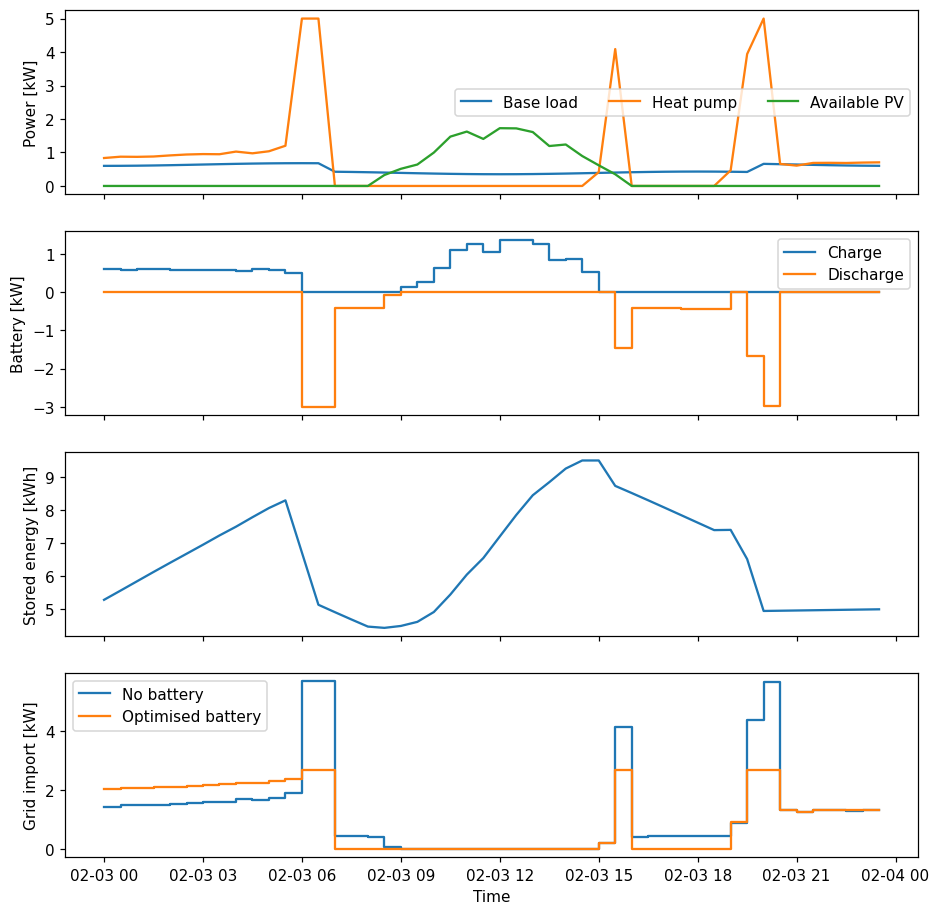

In [6]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 10))
axes[0].plot(conditions["base_load_kw"], label="Base load")
axes[0].plot(conditions.index, heat_pump_power_kw, label="Heat pump")
axes[0].plot(conditions["pv_available_kw"], label="Available PV")
axes[0].set_ylabel("Power [kW]")
axes[0].legend(ncol=3)
axes[1].step(conditions.index, site_solution["battery_charge_kw"], where="post", label="Charge")
axes[1].step(conditions.index, -site_solution["battery_discharge_kw"], where="post", label="Discharge")
axes[1].set_ylabel("Battery [kW]")
axes[1].legend()
axes[2].plot(site_solution["stored_energy_kwh"])
axes[2].set_ylabel("Stored energy [kWh]")
axes[3].step(conditions.index, import_without_storage, where="post", label="No battery")
axes[3].step(conditions.index, site_solution["grid_import_kw"], where="post", label="Optimised battery")
axes[3].set_ylabel("Grid import [kW]")
axes[3].set_xlabel("Time")
axes[3].legend()
plt.show()

## 4. Event-period flexibility

In [7]:
event_mask = (conditions.index.hour >= 16) & (conditions.index.hour < 19)
event_energy_without = float(import_without_storage.loc[event_mask].sum() * dt)
event_energy_with = float(site_solution.loc[event_mask, "grid_import_kw"].sum() * dt)
print(f"Event energy without battery: {event_energy_without:.2f} kWh")
print(f"Event energy with battery: {event_energy_with:.2f} kWh")
print(f"Event-period reduction: {event_energy_without - event_energy_with:.2f} kWh")

Event energy without battery: 1.27 kWh
Event energy with battery: 0.00 kWh
Event-period reduction: 1.27 kWh


## Optional extension

Add an EV that is connected from 18:00 to 07:00. Give it a 7 kW charging limit and require a specified stored-energy increase by departure. Keep the EV availability schedule as a known parameter.

## Discussion

1. Why is a terminal battery-energy condition important?
2. Can the continuous formulation charge and discharge simultaneously? Did it do so here?
3. Why can reducing peak demand increase total cost?
4. Which asset data would need forecasts in real operation?